In [1]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache("../cache")

session = fastf1.get_session(2024, "Monaco", "Q")
session.load()

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '31', '3', '18', '27', '14', '2', '20', '11', '77', '24']


In [2]:
lec_lap = session.laps.pick_drivers("LEC").pick_fastest()
ver_lap = session.laps.pick_drivers("VER").pick_fastest()

print(lec_lap["LapTime"])
print(ver_lap["LapTime"])

0 days 00:01:10.270000
0 days 00:01:10.567000


In [3]:
lec_tel = lec_lap.get_car_data()
ver_tel = ver_lap.get_car_data()

lec_tel.head()

,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime
0,2024-05-25 14:58:18.623,11250.0,280.0,7,99.0,False,12,car,0 days 00:00:00.246000,0 days 01:11:13.940000
1,2024-05-25 14:58:18.983,11408.0,283.0,7,99.0,False,12,car,0 days 00:00:00.606000,0 days 01:11:14.300000
2,2024-05-25 14:58:19.263,11492.0,286.0,7,99.0,False,10,car,0 days 00:00:00.886000,0 days 01:11:14.580000
3,2024-05-25 14:58:19.543,11518.0,286.0,7,99.0,False,8,car,0 days 00:00:01.166000,0 days 01:11:14.860000
4,2024-05-25 14:58:19.783,11197.0,270.0,7,2.0,True,8,car,0 days 00:00:01.406000,0 days 01:11:15.100000


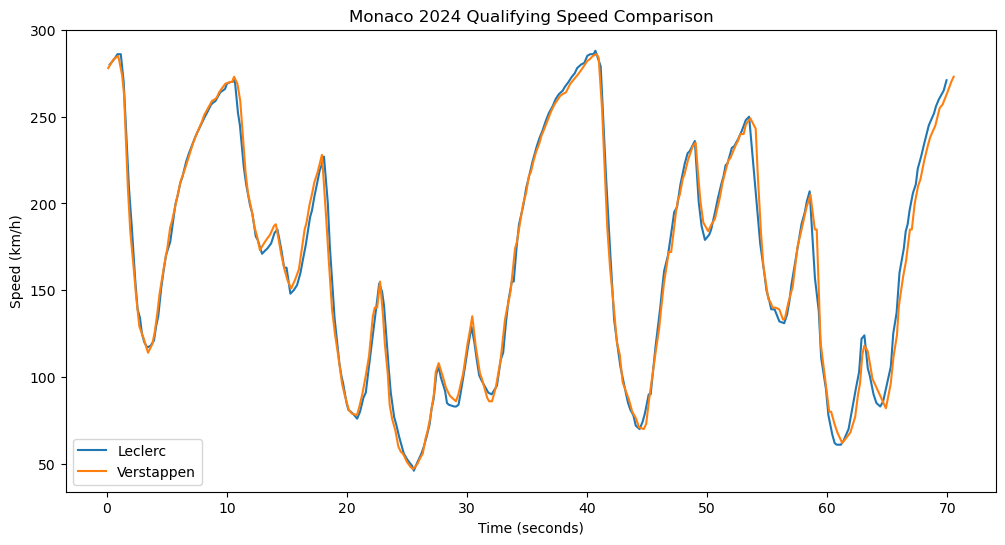

In [4]:
plt.figure(figsize=(12,6))

plt.plot(
    lec_tel["Time"].dt.total_seconds(),
    lec_tel["Speed"],
    label="Leclerc"
)

plt.plot(
    ver_tel["Time"].dt.total_seconds(),
    ver_tel["Speed"],
    label="Verstappen"
)

plt.title("Monaco 2024 Qualifying Speed Comparison")
plt.xlabel("Time (seconds)")
plt.ylabel("Speed (km/h)")
plt.legend()

plt.show()

In [5]:
print("Leclerc Average Speed:",
      round(lec_tel["Speed"].mean(),2))

print("Verstappen Average Speed:",
      round(ver_tel["Speed"].mean(),2))

Leclerc Average Speed: 164.76
Verstappen Average Speed: 167.97


# Conclusion

